In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
housing = pd.read_csv("poorhousingconditions.csv")

In [74]:
def filterLess (x, column, filtVal):
    abc = x[x[column].astype(float) >= filtVal]
    return abc

def filterMore (x, column, filtVal):
    abc = x[x[column].astype(float) <= filtVal]
    return abc


In [75]:
noPoorCon = filterMore(housing, 'PPoorCon', 0)
len(noPoorCon)

107

In [76]:
fivePercent = filterLess(housing, 'PPoorCon', .05)
len(fivePercent)


56

In [77]:
tenPercent = filterLess(housing, 'PPoorCon', .1)
len(tenPercent)



24

In [78]:
df = tenPercent.assign(Neighborhood= [
    'North Fayette', 'North Braddock', 'North Braddock',
    'North Braddock', 'Rankin', 'McKeesport',
    'McKeesport', 'McKeesport', 'Wilkinsburg',
    'Wilkinsburg', 'McKeesport', 'Forward',
    'Wilmerding', 'Duquense', 'Homestead',
    'Frazer Township', 'Harrison Township', 'Wilkinsburg',
    'Braddock', 'Spring Garden', 'Turtle Creek',
    'Etna', 'Clairton', 'Duquense'
    ])

display(df['PPoorCon'].describe())
df.sort_values(by=['TRACT']).set_index('Neighborhood')



count    24.000000
mean      0.154636
std       0.050970
min       0.100973
25%       0.112580
50%       0.129688
75%       0.204757
max       0.256312
Name: PPoorCon, dtype: float64

,TRACT,PPoorCon
Neighborhood,,
Spring Garden,241200,0.126110
Harrison Township,401200,0.124040
Frazer Township,405000,0.116105
Etna,425000,0.106359
Homestead,483800,0.111111
Duquense,486800,0.145397
Duquense,486900,0.100973
Clairton,492700,0.107236
Forward,495000,0.113070


In [79]:
quantity = df['Neighborhood'].value_counts()
avg = df.groupby('Neighborhood').mean()
new = avg.drop(columns=['TRACT']).rename(columns={'PPoorCon': 'AvgPPoorCon'})
new['quantity']= quantity

stupid = new.reset_index()

new

,AvgPPoorCon,quantity
Neighborhood,,
Braddock,0.143345,1
Clairton,0.107236,1
Duquense,0.123185,2
Etna,0.106359,1
Forward,0.113070,1
Frazer Township,0.116105,1
Harrison Township,0.124040,1
Homestead,0.111111,1
McKeesport,0.218043,4


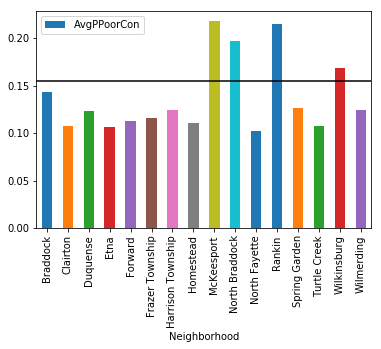

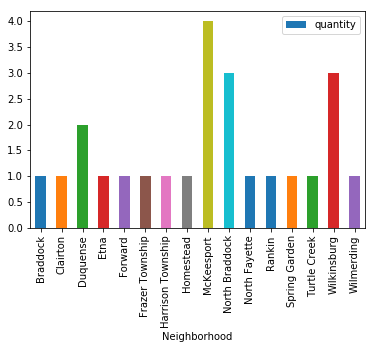

In [36]:
avgComp = new.plot.bar(y = 'AvgPPoorCon')
plt.axhline(df['PPoorCon'].mean(), color='k');

quantityComp = new.plot.bar(y = 'quantity')


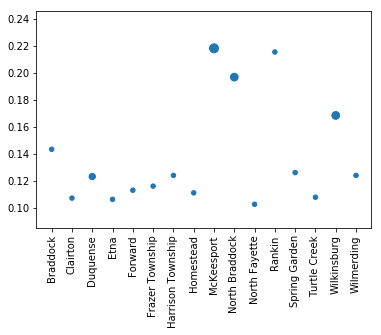

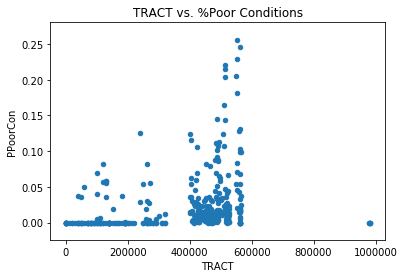

In [72]:
#new.plot(kind='scatter', x='quantity', y='AvgPPoorCon', title="poorest TRACT vs % Avg Poor Conditions")
plt.scatter(x=stupid['Neighborhood'], y=stupid['AvgPPoorCon'], s=stupid['quantity']*20)
plt.xticks(rotation=90)
housing.plot(kind='scatter', x='TRACT', y='PPoorCon', title="TRACT vs. %Poor Conditions");


In [61]:
#x = str(tenPercent['TRACT'])

neighborhood = []

#def f(row):
def f():
    column = df['TRACT']
    val = " "
    for i in range(len(df)):
        if str(column).startswith('564'):  #df.loc[df['A'] == df['B'], 'C'] = 0 
            val = 'North Fayette'
        elif str(column).startswith('561'):
            val = 'Wilkinsburg'
        elif str(column).startswith('552'):
            val = 'McKeesport'
        elif str(column).startswith('514'):
            val = 'Rankin'
        elif str(column).startswith('513'):
            val = 'Braddock'
        elif str(column).startswith('512'):
            val = 'North Braddock'
        elif str(column).startswith('509'):
            val = 'Turtle Creek'
        elif str(column).startswith('508'):
            val = 'Wilmerding'
        elif str(column).startswith('495'):
            val = 'Forward'
        elif str(column).startswith('492'):
            val = 'Clairton'
        elif str(column).startswith('486'):
            val = 'Duquense'
        elif str(column).startswith('483'):
            val = 'Homestead'
        elif str(column).startswith('425'):
            val = 'Etna'
        elif str(column).startswith('405'):
            val = 'Frazer'
        elif str(column).startswith('401'):
            val = 'Harrison'
        elif str(column).startswith('241'):
            val = 'Spring Garden'
        return val
    neighborhood.append(val)
    print(neighborhood)
    return neighborhood
print(neighborhood)
#tenPercent['C'] = tenPercent.apply(f, axis=1)
    
#neighborhood = f(PPoorCon)
#print(neighborhood)
#tenPercent['neighborhood'] = neighborhood
#tenPercent['C'] = tenPercent.apply(f, axis=1)

[]
